# Análisis no supervisado de perfiles departamento–semana

El notebook comienza documentando el análisis univariado previo y luego desarrolla el clustering multivariado solicitado. FIRMS registra focos de calor o anomalías térmicas; una detección no equivale necesariamente a un incendio forestal confirmado.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 30)

## Parte A — Antecedente: clustering univariado

El análisis existente utiliza solamente `log1p(cantidad_detecciones)` sobre observaciones positivas de 2018–2023. No usa `StandardScaler`. Los ceros se separan como `Sin actividad`, se evalúa `k=2…6` y se conserva provisionalmente `k=3`. Esta segmentación de intensidad es distinta del análisis multivariado posterior, que combina actividad FIRMS y condiciones ambientales.

In [2]:
RUTA_DATOS = "data/processed/firms_open_meteo_weekly/open_meteo_firms_weekly_target_available.parquet"
TRAIN_INICIO = pd.Timestamp("2018-01-01")
TRAIN_FIN = pd.Timestamp("2023-12-31")

datos = pd.read_parquet(RUTA_DATOS)
datos["fecha_inicio_semana"] = pd.to_datetime(datos["fecha_inicio_semana"], errors="raise")
columnas_requeridas = {"fecha_inicio_semana", "cantidad_detecciones", "nivel_actividad_firms"}
assert columnas_requeridas.issubset(datos.columns)
assert datos[list(columnas_requeridas)].isna().sum().sum() == 0
assert datos["cantidad_detecciones"].ge(0).all()

train = datos.loc[datos["fecha_inicio_semana"].between(TRAIN_INICIO, TRAIN_FIN)].copy()
train_positivos = train.loc[train["cantidad_detecciones"].gt(0)].copy()

pd.DataFrame({
    "particion": ["train completo", "train positivo", "ceros separados", "fuera del ajuste"],
    "observaciones": [len(train), len(train_positivos), train["cantidad_detecciones"].eq(0).sum(), len(datos) - len(train)],
    "fecha_min": [train["fecha_inicio_semana"].min(), train_positivos["fecha_inicio_semana"].min(), train["fecha_inicio_semana"].min(), datos.loc[~datos.index.isin(train.index), "fecha_inicio_semana"].min()],
    "fecha_max": [train["fecha_inicio_semana"].max(), train_positivos["fecha_inicio_semana"].max(), train["fecha_inicio_semana"].max(), datos.loc[~datos.index.isin(train.index), "fecha_inicio_semana"].max()]
})

,particion,observaciones,fecha_min,fecha_max
0,train completo,5947,2018-01-01,2023-12-25
1,train positivo,2331,2018-01-01,2023-12-25
2,ceros separados,3616,2018-01-01,2023-12-25
3,fuera del ajuste,1976,2024-01-01,2025-12-22


## Separación de ceros y transformación

`cantidad_detecciones == 0` representa ausencia de actividad FIRMS observada y no participa en K-Means. Puede mantenerse como una categoría separada, denominada `Sin actividad`. K-Means diferencia niveles solamente entre observaciones positivas.

Se aplica `log1p` porque el conteo positivo es muy asimétrico. La transformación reduce la influencia de valores extremadamente grandes sobre las distancias, pero no implica que la distribución resultante sea normal.

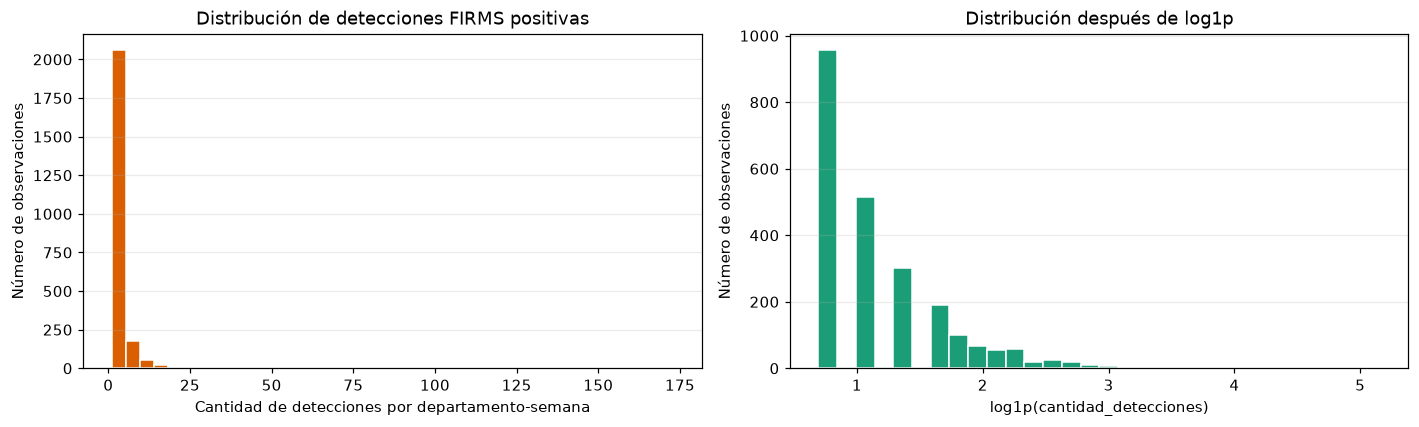

In [3]:
X = np.log1p(train_positivos[["cantidad_detecciones"]].astype(float))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(train_positivos["cantidad_detecciones"], bins=40, color="#d95f02", edgecolor="white")
axes[0].set_title("Distribución de detecciones FIRMS positivas")
axes[0].set_xlabel("Cantidad de detecciones por departamento-semana")
axes[0].set_ylabel("Número de observaciones")
axes[0].grid(axis="y", alpha=0.25)

axes[1].hist(X["cantidad_detecciones"], bins=30, color="#1b9e77", edgecolor="white")
axes[1].set_title("Distribución después de log1p")
axes[1].set_xlabel("log1p(cantidad_detecciones)")
axes[1].set_ylabel("Número de observaciones")
axes[1].grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Evaluación del número de clusters

Se comparan `k=2, 3, 4, 5, 6` usando exactamente las mismas observaciones positivas y la misma transformación `log1p`. Se consideran inercia, Silhouette, Davies-Bouldin, tamaños y centroides. La selección no depende automáticamente de una sola métrica: también se considera la interpretabilidad y la presencia de clusters muy pequeños.

In [4]:
resultados_k = []
modelos_k = {}

for k in range(2, 7):
    modelo_k = KMeans(n_clusters=k, random_state=42, n_init=20)
    etiquetas_k = modelo_k.fit_predict(X)
    orden_k = np.argsort(modelo_k.cluster_centers_.ravel())
    modelos_k[k] = modelo_k
    resultados_k.append({
        "k": k,
        "inercia": modelo_k.inertia_,
        "silhouette": silhouette_score(X, etiquetas_k),
        "davies_bouldin": davies_bouldin_score(X, etiquetas_k),
        "tamanos_clusters": [int((etiquetas_k == cluster).sum()) for cluster in orden_k],
        "centroides_detecciones": np.expm1(modelo_k.cluster_centers_.ravel()[orden_k]).round(3).tolist()
    })

resultados_k = pd.DataFrame(resultados_k)
resultados_k

,k,inercia,silhouette,davies_bouldin,tamanos_clusters,centroides_detecciones
0,2,219.405295,0.672676,0.557854,"[1473, 858]","[1.305, 4.844]"
1,3,101.336662,0.740228,0.474138,"[958, 1005, 368]","[1.0, 2.6, 7.632]"
2,4,51.655095,0.779255,0.465187,"[958, 816, 410, 147]","[1.0, 2.336, 4.876, 11.509]"
3,5,29.742318,0.856908,0.406882,"[958, 515, 490, 278, 90]","[1.0, 2.0, 3.36, 6.216, 14.017]"
4,6,19.571007,0.859183,0.390311,"[958, 515, 490, 256, 109, 3]","[1.0, 2.0, 3.36, 6.016, 12.176, 87.168]"


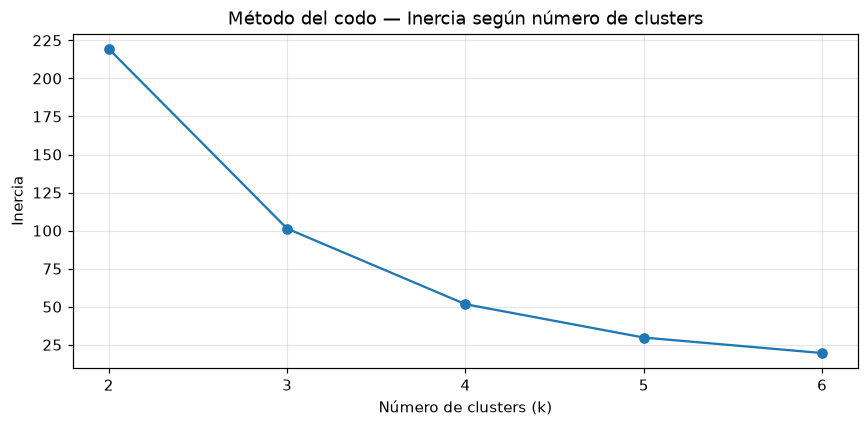

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(resultados_k["k"], resultados_k["inercia"], marker="o", color="#1f77b4")
ax.set_title("Método del codo — Inercia según número de clusters")
ax.set_xlabel("Número de clusters (k)")
ax.set_ylabel("Inercia")
ax.set_xticks(resultados_k["k"])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

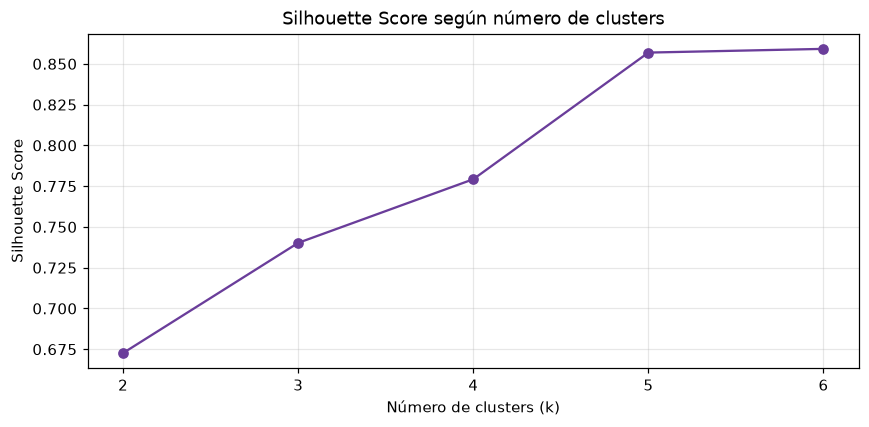

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(resultados_k["k"], resultados_k["silhouette"], marker="o", color="#6a3d9a")
ax.set_title("Silhouette Score según número de clusters")
ax.set_xlabel("Número de clusters (k)")
ax.set_ylabel("Silhouette Score")
ax.set_xticks(resultados_k["k"])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Selección del modelo final

Silhouette mejora al aumentar `k` dentro del rango evaluado, pero `k=6` crea un cluster de solamente tres observaciones extremas. El codo presenta mejoras decrecientes y no determina por sí solo un único valor. Se conserva `k=3` como solución exploratoria por parsimonia, tamaños interpretables y comparabilidad con los tres niveles positivos actuales. Esto no demuestra que tres clusters sean la única ni la mejor estructura posible.

In [7]:
K_FINAL = 3
kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
train_positivos["cluster_original"] = kmeans.fit_predict(X)

orden_clusters = np.argsort(kmeans.cluster_centers_.ravel())
nombres_ordenados = ["Bajo", "Moderado", "Alto"]
mapa_clusters = {int(cluster): nombre for cluster, nombre in zip(orden_clusters, nombres_ordenados)}
train_positivos["nivel_actividad_kmeans"] = train_positivos["cluster_original"].map(mapa_clusters)
assert train_positivos["nivel_actividad_kmeans"].notna().all()

## Centroides, características y fronteras observadas

Los centroides se presentan en la escala `log1p` y se convierten con `expm1`. Representan el centro del cluster en la escala transformada, no un umbral definido manualmente. Las etiquetas se asignan después de ordenar los centroides.

In [8]:
centroides = pd.DataFrame([
    {
        "cluster_original": int(cluster),
        "nivel": mapa_clusters[int(cluster)],
        "centroide_log": float(kmeans.cluster_centers_[cluster, 0]),
        "centroide_detecciones": float(np.expm1(kmeans.cluster_centers_[cluster, 0]))
    }
    for cluster in orden_clusters
])
centroides.round(4)

,cluster_original,nivel,centroide_log,centroide_detecciones
0,0,Bajo,0.6931,1.0000
1,2,Moderado,1.2808,2.5997
2,1,Alto,2.1555,7.6322


In [9]:
resumen_clusters = (
    train_positivos.groupby("nivel_actividad_kmeans", observed=True)["cantidad_detecciones"]
    .agg(
        cantidad_observaciones="count",
        minimo="min",
        percentil_25=lambda x: x.quantile(0.25),
        mediana="median",
        media="mean",
        percentil_75=lambda x: x.quantile(0.75),
        maximo="max"
    )
    .reindex(nombres_ordenados)
)
resumen_clusters["porcentaje_positivos"] = resumen_clusters["cantidad_observaciones"].div(len(train_positivos)).mul(100)
resumen_clusters["centroide_detecciones"] = centroides.set_index("nivel")["centroide_detecciones"]
resumen_clusters = resumen_clusters[["cantidad_observaciones", "porcentaje_positivos", "minimo", "percentil_25", "mediana", "media", "percentil_75", "maximo", "centroide_detecciones"]]
resumen_clusters.round(3)

,cantidad_observaciones,porcentaje_positivos,minimo,percentil_25,mediana,media,percentil_75,maximo,centroide_detecciones
nivel_actividad_kmeans,,,,,,,,,
Bajo,958,41.098,1,1.0,1.0,1.0,1.0,1,1.000
Moderado,1005,43.115,2,2.0,2.0,2.676,3.0,4,2.600
Alto,368,15.787,5,5.0,7.0,8.832,9.0,173,7.632


In [10]:
rangos_observados = (
    train_positivos.groupby("nivel_actividad_kmeans", observed=True)["cantidad_detecciones"]
    .agg(minimo_observado="min", maximo_observado="max", n="count")
    .reindex(nombres_ordenados)
)
rangos_observados.index.name = "nivel"
rangos_observados

,minimo_observado,maximo_observado,n
nivel,,,
Bajo,1,1,958
Moderado,2,4,1005
Alto,5,173,368


Los rangos anteriores son consecuencia del ajuste de K-Means sobre los valores observados. No fueron establecidos previamente como umbrales.

## Comparación descriptiva con las clases actuales

`nivel_actividad_firms` no se utiliza como entrada. La comparación permite medir cambios respecto de los cortes actuales, pero no demuestra automáticamente que alguno de los métodos sea correcto.

In [11]:
orden_actual_positivo = ["Bajo", "Moderado", "Alto"]
tabla_cruzada = pd.crosstab(
    train_positivos["nivel_actividad_firms"].astype("string"),
    train_positivos["nivel_actividad_kmeans"],
    rownames=["Clase FIRMS actual"], colnames=["Cluster K-Means"]
).reindex(index=orden_actual_positivo, columns=nombres_ordenados, fill_value=0)
tabla_cruzada

Cluster K-Means,Bajo,Moderado,Alto
Clase FIRMS actual,,,
Bajo,958,0,0
Moderado,0,816,0
Alto,0,189,368


In [12]:
comparacion_cortes = pd.DataFrame({
    "clase": ["Sin actividad", "Bajo", "Moderado", "Alto"],
    "cortes_actuales": ["0", "1", "2–3", ">=4"],
    "rangos_observados_kmeans": ["0 (separado)"] + [
        f"{int(rangos_observados.loc[nivel, 'minimo_observado'])}–{int(rangos_observados.loc[nivel, 'maximo_observado'])}"
        for nivel in nombres_ordenados
    ]
})
comparacion_cortes

,clase,cortes_actuales,rangos_observados_kmeans
0,Sin actividad,0,0 (separado)
1,Bajo,1,1–1
2,Moderado,2–3,2–4
3,Alto,>=4,5–173


## Visualización del clustering final

Al ser un clustering univariado, los puntos se muestran sobre un único eje de cantidad de detecciones. Las líneas discontinuas representan los centroides convertidos a la escala original.

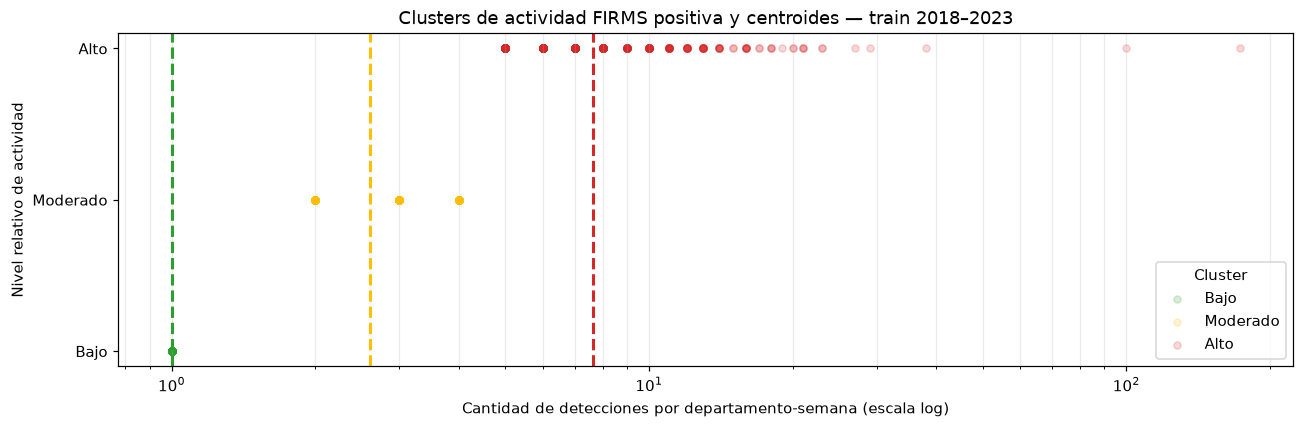

In [13]:
colores_clusters = {"Bajo": "#2ca02c", "Moderado": "#ffbf00", "Alto": "#d62728"}
fig, ax = plt.subplots(figsize=(12, 4))
for posicion, nivel in enumerate(nombres_ordenados):
    valores = train_positivos.loc[train_positivos["nivel_actividad_kmeans"].eq(nivel), "cantidad_detecciones"]
    ax.scatter(valores, np.full(len(valores), posicion), alpha=0.18, s=22, color=colores_clusters[nivel], label=nivel)
    centroide = centroides.set_index("nivel").loc[nivel, "centroide_detecciones"]
    ax.axvline(centroide, color=colores_clusters[nivel], linestyle="--", linewidth=2)
ax.set_xscale("log")
ax.set_yticks(range(len(nombres_ordenados)), labels=nombres_ordenados)
ax.set_title("Clusters de actividad FIRMS positiva y centroides — train 2018–2023")
ax.set_xlabel("Cantidad de detecciones por departamento-semana (escala log)")
ax.set_ylabel("Nivel relativo de actividad")
ax.grid(axis="x", alpha=0.25, which="both")
ax.legend(title="Cluster")
plt.tight_layout()
plt.show()

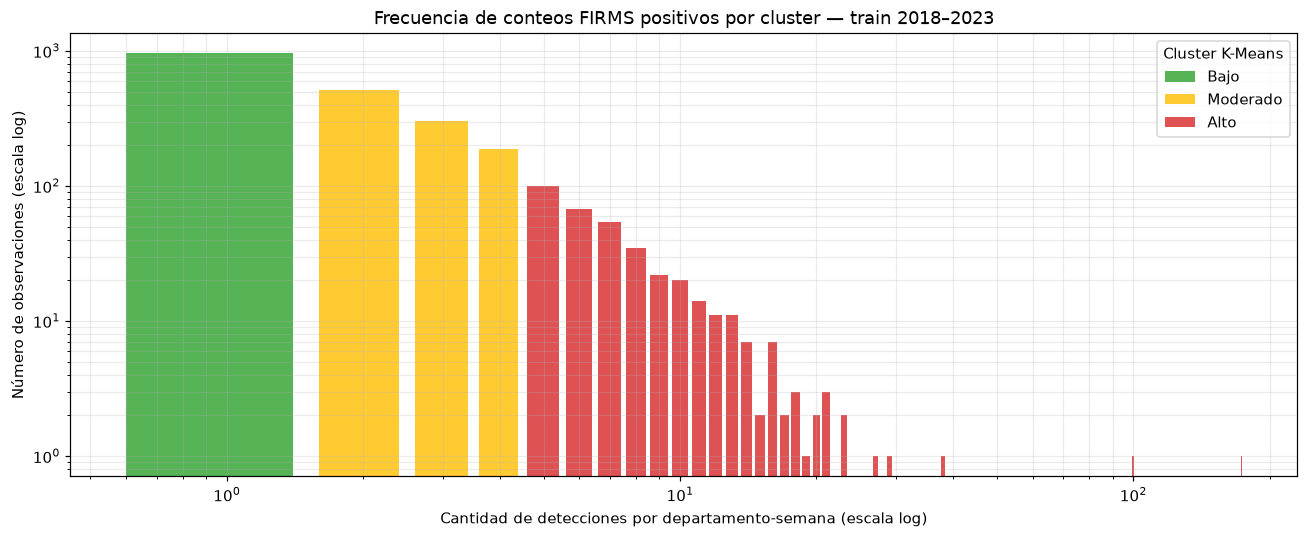

In [14]:
frecuencias_cluster = (
    train_positivos.groupby(["nivel_actividad_kmeans", "cantidad_detecciones"], observed=True)
    .size().rename("frecuencia").reset_index()
)
fig, ax = plt.subplots(figsize=(12, 5))
for nivel in nombres_ordenados:
    parte = frecuencias_cluster.loc[frecuencias_cluster["nivel_actividad_kmeans"].eq(nivel)]
    ax.bar(parte["cantidad_detecciones"], parte["frecuencia"], color=colores_clusters[nivel], alpha=0.8, label=nivel)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Frecuencia de conteos FIRMS positivos por cluster — train 2018–2023")
ax.set_xlabel("Cantidad de detecciones por departamento-semana (escala log)")
ax.set_ylabel("Número de observaciones (escala log)")
ax.legend(title="Cluster K-Means")
ax.grid(alpha=0.25, which="both")
plt.tight_layout()
plt.show()

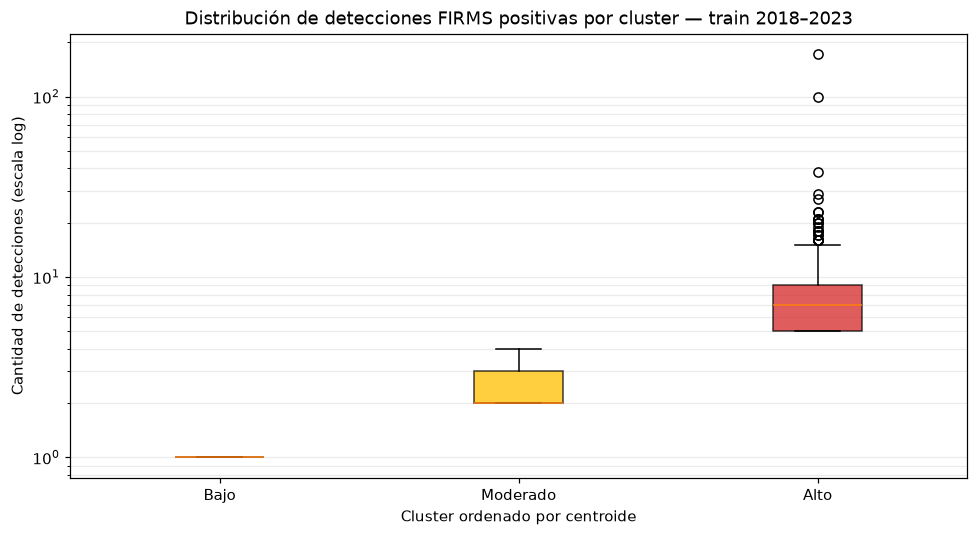

In [15]:
valores_boxplot = [
    train_positivos.loc[train_positivos["nivel_actividad_kmeans"].eq(nivel), "cantidad_detecciones"].astype(float)
    for nivel in nombres_ordenados
]
fig, ax = plt.subplots(figsize=(9, 5))
box = ax.boxplot(valores_boxplot, tick_labels=nombres_ordenados, patch_artist=True, showfliers=True)
for patch, nivel in zip(box["boxes"], nombres_ordenados):
    patch.set_facecolor(colores_clusters[nivel])
    patch.set_alpha(0.75)
ax.set_yscale("log")
ax.set_title("Distribución de detecciones FIRMS positivas por cluster — train 2018–2023")
ax.set_xlabel("Cluster ordenado por centroide")
ax.set_ylabel("Cantidad de detecciones (escala log)")
ax.grid(axis="y", alpha=0.25, which="both")
plt.tight_layout()
plt.show()

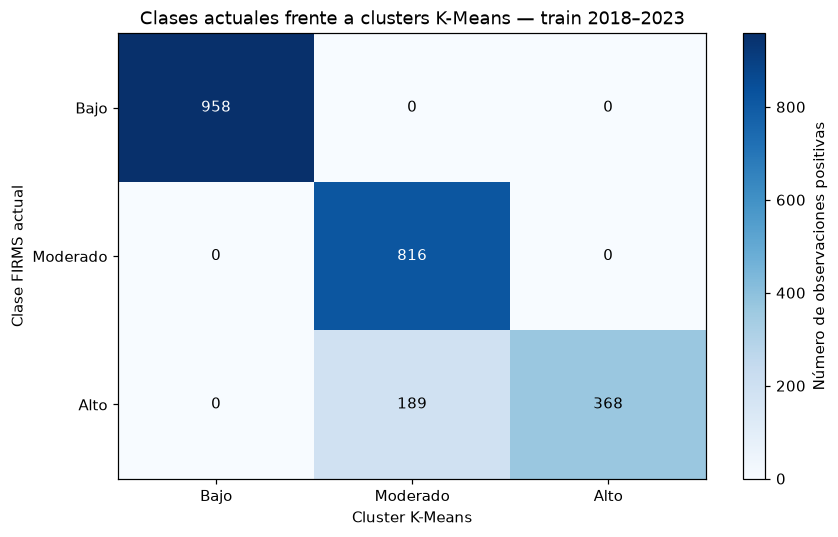

In [16]:
matriz = tabla_cruzada.to_numpy()
fig, ax = plt.subplots(figsize=(8, 5))
imagen = ax.imshow(matriz, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(nombres_ordenados)), labels=nombres_ordenados)
ax.set_yticks(range(len(orden_actual_positivo)), labels=orden_actual_positivo)
ax.set_title("Clases actuales frente a clusters K-Means — train 2018–2023")
ax.set_xlabel("Cluster K-Means")
ax.set_ylabel("Clase FIRMS actual")
for fila in range(matriz.shape[0]):
    for columna in range(matriz.shape[1]):
        ax.text(columna, fila, f"{matriz[fila, columna]:,}", ha="center", va="center", color="white" if matriz[fila, columna] > matriz.max() / 2 else "black")
fig.colorbar(imagen, ax=ax, label="Número de observaciones positivas")
plt.tight_layout()
plt.show()

## Estabilidad básica

Se repite `k=3` con varias semillas y `n_init=20`. Se comparan centroides ordenados; esto permite detectar sensibilidad básica sin convertirla en un estudio exhaustivo de estabilidad.

In [17]:
semillas = [0, 1, 7, 21, 42, 99]
centroides_estabilidad = []
for semilla in semillas:
    modelo_estabilidad = KMeans(n_clusters=K_FINAL, random_state=semilla, n_init=20).fit(X)
    centros_ordenados = np.expm1(np.sort(modelo_estabilidad.cluster_centers_.ravel()))
    centroides_estabilidad.append({
        "random_state": semilla,
        "centroide_bajo": centros_ordenados[0],
        "centroide_moderado": centros_ordenados[1],
        "centroide_alto": centros_ordenados[2]
    })
centroides_estabilidad = pd.DataFrame(centroides_estabilidad)
centroides_estabilidad.round(4)

,random_state,centroide_bajo,centroide_moderado,centroide_alto
0,0,1.0,2.5997,7.6322
1,1,1.0,2.7700,8.8871
2,7,1.0,2.5997,7.6322
3,21,1.0,2.5997,7.6322
4,42,1.0,2.5997,7.6322
5,99,1.0,2.5997,7.6322


# Evaluación temporal externa 2024–2025

El K-Means permanece congelado con los centroides ajustados en 2018–2023. Para 2024–2025 sólo se aplica `log1p` a las observaciones positivas y luego `kmeans.predict`. Los ceros continúan separados como `Sin actividad`. Esta sección evalúa estabilidad temporal de la segmentación, no capacidad predictiva.

In [18]:
PERIODO_POSTERIOR_INICIO = pd.Timestamp("2024-01-01")
PERIODO_POSTERIOR_FIN = pd.Timestamp("2025-12-31")
orden_niveles = ["Sin actividad", "Bajo", "Moderado", "Alto"]

periodo_posterior = datos.loc[
    datos["fecha_inicio_semana"].between(PERIODO_POSTERIOR_INICIO, PERIODO_POSTERIOR_FIN)
].copy()
posterior_positivos = periodo_posterior.loc[periodo_posterior["cantidad_detecciones"].gt(0)].copy()
X_posterior = np.log1p(posterior_positivos[["cantidad_detecciones"]].astype(float))

#Aplicamos el modelo congelado sin volver a entrenarlo
posterior_positivos["cluster_original"] = kmeans.predict(X_posterior)
posterior_positivos["nivel_actividad_kmeans"] = posterior_positivos["cluster_original"].map(mapa_clusters)
periodo_posterior["nivel_actividad_kmeans"] = "Sin actividad"
periodo_posterior.loc[posterior_positivos.index, "nivel_actividad_kmeans"] = posterior_positivos["nivel_actividad_kmeans"]
periodo_posterior["nivel_actividad_kmeans"] = pd.Categorical(periodo_posterior["nivel_actividad_kmeans"], categories=orden_niveles, ordered=True)

distribucion_posterior = periodo_posterior["nivel_actividad_kmeans"].value_counts().reindex(orden_niveles, fill_value=0).rename("observaciones").to_frame()
distribucion_posterior["porcentaje"] = distribucion_posterior["observaciones"].div(len(periodo_posterior)).mul(100)
distribucion_posterior.round(3)

,observaciones,porcentaje
nivel_actividad_kmeans,,
Sin actividad,1351,68.370
Bajo,279,14.119
Moderado,261,13.209
Alto,85,4.302


In [19]:
resumen_posterior = (
    posterior_positivos.groupby("nivel_actividad_kmeans", observed=True)["cantidad_detecciones"]
    .agg(
        observaciones="count",
        minimo="min",
        p25=lambda x: x.quantile(0.25),
        mediana="median",
        media="mean",
        p75=lambda x: x.quantile(0.75),
        maximo="max"
    )
    .reindex(nombres_ordenados)
)
resumen_posterior["porcentaje"] = resumen_posterior["observaciones"].div(len(posterior_positivos)).mul(100)
resumen_posterior = resumen_posterior[["observaciones", "porcentaje", "minimo", "p25", "mediana", "media", "p75", "maximo"]]
resumen_posterior.round(3)

,observaciones,porcentaje,minimo,p25,mediana,media,p75,maximo
nivel_actividad_kmeans,,,,,,,,
Bajo,279,44.64,1,1.0,1.0,1.0,1.0,1
Moderado,261,41.76,2,2.0,2.0,2.613,3.0,4
Alto,85,13.6,5,5.0,6.0,7.647,9.0,22


In [20]:
distribucion_train = pd.concat([
    pd.Series({"Sin actividad": train["cantidad_detecciones"].eq(0).sum()}),
    train_positivos["nivel_actividad_kmeans"].value_counts()
]).groupby(level=0).sum().reindex(orden_niveles, fill_value=0)

comparacion_temporal = pd.DataFrame({
    "% 2018–2023": distribucion_train.div(len(train)).mul(100),
    "% 2024–2025": distribucion_posterior["porcentaje"]
})
comparacion_temporal["diferencia pp"] = comparacion_temporal["% 2024–2025"] - comparacion_temporal["% 2018–2023"]
comparacion_temporal.index.name = "nivel"
comparacion_temporal.round(3)

,% 2018–2023,% 2024–2025,diferencia pp
nivel,,,
Sin actividad,60.804,68.370,7.567
Bajo,16.109,14.119,-1.990
Moderado,16.899,13.209,-3.691
Alto,6.188,4.302,-1.886


In [21]:
rangos_posteriores = (
    posterior_positivos.groupby("nivel_actividad_kmeans", observed=True)["cantidad_detecciones"]
    .agg(minimo_observado_2024_2025="min", maximo_observado_2024_2025="max", n="count")
    .reindex(nombres_ordenados)
)
rangos_posteriores.index.name = "nivel"
rangos_posteriores

,minimo_observado_2024_2025,maximo_observado_2024_2025,n
nivel,,,
Bajo,1,1,279
Moderado,2,4,261
Alto,5,22,85


## Visualizaciones de estabilidad temporal

Las proporciones se calculan sobre cada período completo, incluyendo `Sin actividad`. Las distribuciones de conteos comparan sólo observaciones positivas. Los centroides mostrados para 2024–2025 son exactamente los ajustados con 2018–2023.

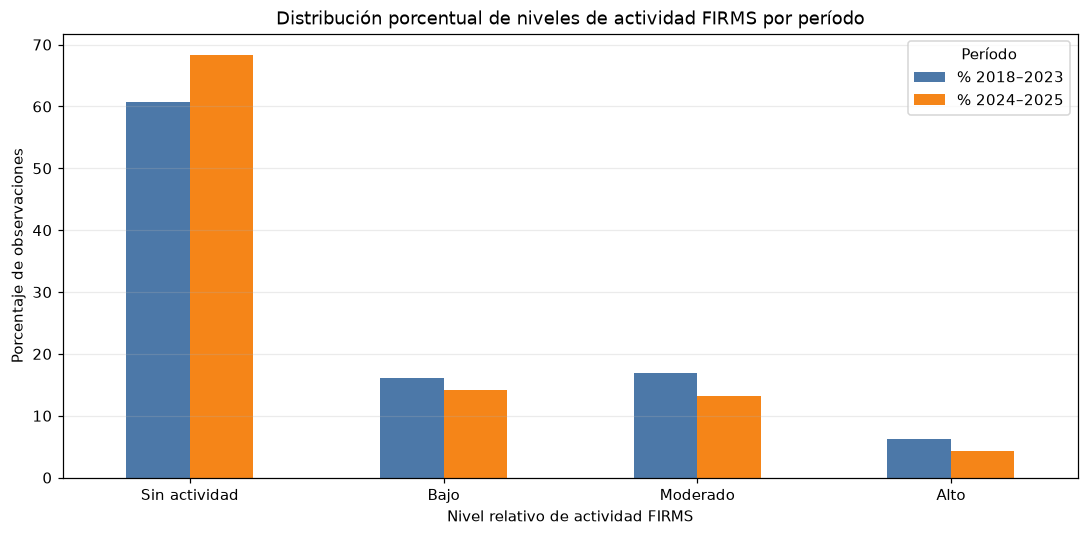

In [22]:
comparacion_temporal[["% 2018–2023", "% 2024–2025"]].plot(kind="bar", figsize=(10, 5), color=["#4c78a8", "#f58518"])
plt.title("Distribución porcentual de niveles de actividad FIRMS por período")
plt.xlabel("Nivel relativo de actividad FIRMS")
plt.ylabel("Porcentaje de observaciones")
plt.xticks(rotation=0)
plt.legend(title="Período")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

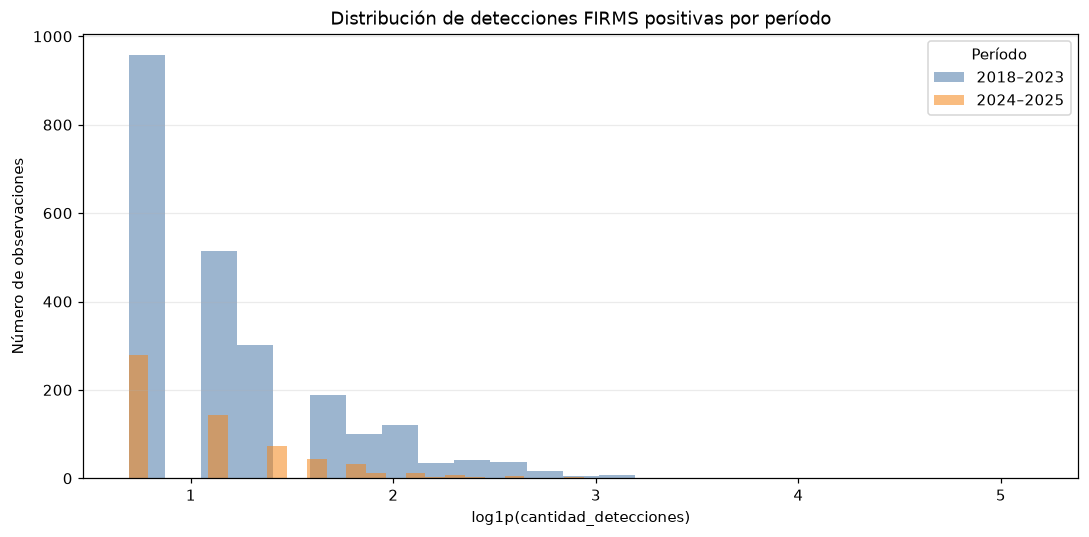

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.log1p(train_positivos["cantidad_detecciones"].astype(float)), bins=25, alpha=0.55, label="2018–2023", color="#4c78a8")
ax.hist(np.log1p(posterior_positivos["cantidad_detecciones"].astype(float)), bins=25, alpha=0.55, label="2024–2025", color="#f58518")
ax.set_title("Distribución de detecciones FIRMS positivas por período")
ax.set_xlabel("log1p(cantidad_detecciones)")
ax.set_ylabel("Número de observaciones")
ax.legend(title="Período")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

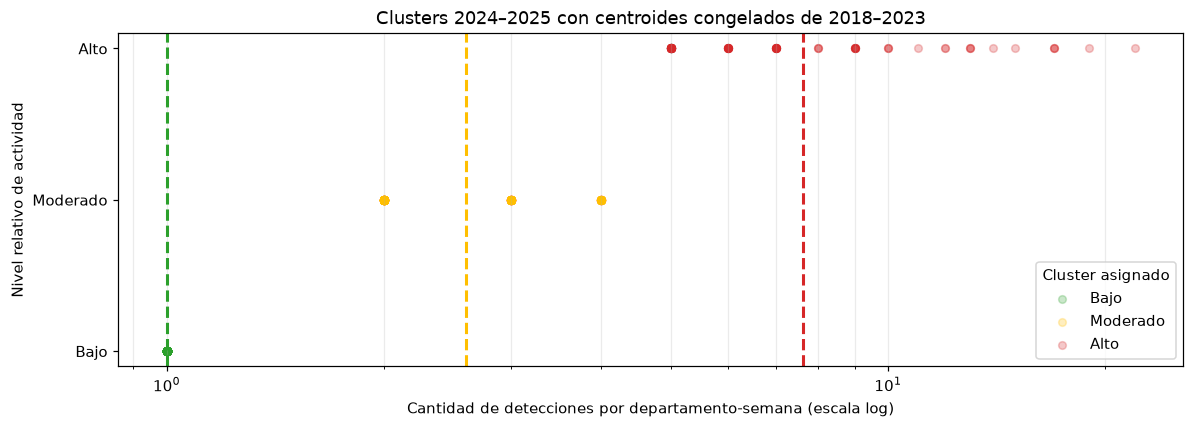

In [24]:
fig, ax = plt.subplots(figsize=(11, 4))
for posicion, nivel in enumerate(nombres_ordenados):
    valores = posterior_positivos.loc[posterior_positivos["nivel_actividad_kmeans"].eq(nivel), "cantidad_detecciones"]
    ax.scatter(valores, np.full(len(valores), posicion), alpha=0.25, s=25, color=colores_clusters[nivel], label=nivel)
    centroide_congelado = centroides.set_index("nivel").loc[nivel, "centroide_detecciones"]
    ax.axvline(centroide_congelado, color=colores_clusters[nivel], linestyle="--", linewidth=2)
ax.set_xscale("log")
ax.set_yticks(range(len(nombres_ordenados)), labels=nombres_ordenados)
ax.set_title("Clusters 2024–2025 con centroides congelados de 2018–2023")
ax.set_xlabel("Cantidad de detecciones por departamento-semana (escala log)")
ax.set_ylabel("Nivel relativo de actividad")
ax.legend(title="Cluster asignado")
ax.grid(axis="x", alpha=0.25, which="both")
plt.tight_layout()
plt.show()

## Lectura prudente de la estabilidad temporal

Los tres grupos permanecen poblados y conservan rangos observados interpretables en 2024–2025. Aumenta la proporción `Sin actividad` y disminuyen los tres niveles positivos, especialmente Moderado y Alto. El máximo posterior es 22, por debajo de los extremos 100 y 173 del entrenamiento. Estas diferencias describen un cambio de composición entre períodos; por sí solas no demuestran deterioro ni generalización predictiva.

# Caracterización ambiental de los niveles

Las variables ambientales se utilizan únicamente para describir los grupos ya asignados. No entran al ajuste de K-Means. Las comparaciones son asociaciones dentro del dataset y no implican causalidad. La dirección dominante del viento es una variable angular: se informa su disponibilidad, pero no se resume con media, mediana y cuartiles lineales.

In [25]:
variables_ambientales = [
    "temperature_2m_max_mean_weekly",
    "temperature_2m_max_weekly",
    "temperature_2m_min_mean_weekly",
    "temperature_2m_min_weekly",
    "relative_humidity_2m_min_mean_weekly",
    "relative_humidity_2m_min_weekly",
    "relative_humidity_2m_max_mean_weekly",
    "relative_humidity_2m_max_weekly",
    "wind_speed_10m_max_mean_weekly",
    "wind_speed_10m_max_weekly",
    "precipitation_sum_weekly",
    "precipitation_max_daily_weekly",
    "et0_fao_evapotranspiration_sum_weekly",
    "et0_fao_evapotranspiration_max_daily_weekly",
    "wind_direction_10m_resultant_length_spatial_daily_mean_weekly",
    "wind_direction_10m_dominant_circular_mean_weekly",
    "wind_direction_10m_resultant_length_weekly"
]
assert set(variables_ambientales).issubset(datos.columns)

disponibilidad_ambiental = pd.DataFrame([
    {
        "variable": variable,
        "tipo": str(datos[variable].dtype),
        "valores_no_nulos": int(datos[variable].notna().sum()),
        "porcentaje_disponible": datos[variable].notna().mean() * 100,
        "fecha_min": datos.loc[datos[variable].notna(), "fecha_inicio_semana"].min(),
        "fecha_max": datos.loc[datos[variable].notna(), "fecha_inicio_semana"].max()
    }
    for variable in variables_ambientales
])
disponibilidad_ambiental_mostrar = disponibilidad_ambiental.copy()
disponibilidad_ambiental_mostrar["porcentaje_disponible"] = disponibilidad_ambiental_mostrar["porcentaje_disponible"].round(3)
disponibilidad_ambiental_mostrar

,variable,tipo,valores_no_nulos,porcentaje_disponible,fecha_min,fecha_max
0,temperature_2m_max_mean_weekly,float64,7923,100.0,2018-01-01,2025-12-22
1,temperature_2m_max_weekly,float64,7923,100.0,2018-01-01,2025-12-22
2,temperature_2m_min_mean_weekly,float64,7923,100.0,2018-01-01,2025-12-22
3,temperature_2m_min_weekly,float64,7923,100.0,2018-01-01,2025-12-22
4,relative_humidity_2m_min_mean_weekly,float64,7923,100.0,2018-01-01,2025-12-22
5,relative_humidity_2m_min_weekly,int64,7923,100.0,2018-01-01,2025-12-22
6,relative_humidity_2m_max_mean_weekly,float64,7923,100.0,2018-01-01,2025-12-22
7,relative_humidity_2m_max_weekly,int64,7923,100.0,2018-01-01,2025-12-22
8,wind_speed_10m_max_mean_weekly,float64,7923,100.0,2018-01-01,2025-12-22
9,wind_speed_10m_max_weekly,float64,7923,100.0,2018-01-01,2025-12-22


In [26]:
#Asignamos niveles a todo el período sin volver a ajustar K-Means
datos_caracterizados = datos.copy()
datos_caracterizados["nivel_actividad_kmeans"] = "Sin actividad"
positivos_completos = datos_caracterizados["cantidad_detecciones"].gt(0)
X_positivos_completos = np.log1p(datos_caracterizados.loc[positivos_completos, ["cantidad_detecciones"]].astype(float))
clusters_completos = kmeans.predict(X_positivos_completos)
datos_caracterizados.loc[positivos_completos, "nivel_actividad_kmeans"] = pd.Series(clusters_completos, index=datos_caracterizados.index[positivos_completos]).map(mapa_clusters)
datos_caracterizados["nivel_actividad_kmeans"] = pd.Categorical(datos_caracterizados["nivel_actividad_kmeans"], categories=orden_niveles, ordered=True)

cobertura_por_nivel = datos_caracterizados.groupby("nivel_actividad_kmeans", observed=True)[variables_ambientales].apply(lambda grupo: grupo.notna().mean().mul(100)).reindex(orden_niveles)
cobertura_por_nivel.round(2)

,temperature_2m_max_mean_weekly,temperature_2m_max_weekly,temperature_2m_min_mean_weekly,temperature_2m_min_weekly,relative_humidity_2m_min_mean_weekly,relative_humidity_2m_min_weekly,relative_humidity_2m_max_mean_weekly,relative_humidity_2m_max_weekly,wind_speed_10m_max_mean_weekly,wind_speed_10m_max_weekly,precipitation_sum_weekly,precipitation_max_daily_weekly,et0_fao_evapotranspiration_sum_weekly,et0_fao_evapotranspiration_max_daily_weekly,wind_direction_10m_resultant_length_spatial_daily_mean_weekly,wind_direction_10m_dominant_circular_mean_weekly,wind_direction_10m_resultant_length_weekly
nivel_actividad_kmeans,,,,,,,,,,,,,,,,,
Sin actividad,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
Bajo,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
Moderado,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
Alto,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0


In [27]:
variables_ambientales_descriptivas = [
    variable for variable in variables_ambientales
    if variable != "wind_direction_10m_dominant_circular_mean_weekly"
]

filas_resumen_ambiental = []
for variable in variables_ambientales_descriptivas:
    for nivel in orden_niveles:
        valores = datos_caracterizados.loc[datos_caracterizados["nivel_actividad_kmeans"].eq(nivel), variable].dropna()
        filas_resumen_ambiental.append({
            "variable": variable,
            "nivel": nivel,
            "n": len(valores),
            "media": valores.mean(),
            "mediana": valores.median(),
            "desviacion_estandar": valores.std(),
            "p25": valores.quantile(0.25),
            "p75": valores.quantile(0.75)
        })
resumen_ambiental = pd.DataFrame(filas_resumen_ambiental)
resumen_ambiental.round(3)

,variable,nivel,n,media,mediana,desviacion_estandar,p25,p75
0,temperature_2m_max_mean_weekly,Sin actividad,4967,21.827,21.733,5.716,17.265,26.397
1,temperature_2m_max_mean_weekly,Bajo,1237,23.043,23.412,5.054,19.112,26.933
2,temperature_2m_max_mean_weekly,Moderado,1266,22.346,22.119,4.987,18.535,26.099
3,temperature_2m_max_mean_weekly,Alto,453,21.242,20.041,5.196,17.480,24.689
4,temperature_2m_max_weekly,Sin actividad,4967,26.159,26.100,5.839,21.900,30.700
...,...,...,...,...,...,...,...,...
59,wind_direction_10m_resultant_length_spatial_da...,Alto,453,0.989,0.995,0.017,0.990,0.998
60,wind_direction_10m_resultant_length_weekly,Sin actividad,4967,0.517,0.520,0.229,0.346,0.695
61,wind_direction_10m_resultant_length_weekly,Bajo,1237,0.514,0.521,0.232,0.339,0.689
62,wind_direction_10m_resultant_length_weekly,Moderado,1266,0.497,0.484,0.229,0.320,0.677


## Variables ambientales seleccionadas para visualizar

Se muestran cuatro variables representativas y con cobertura completa. Los boxplots permiten comparar mediana, dispersión y valores extremos sin asumir normalidad. Las diferencias observadas son descriptivas.

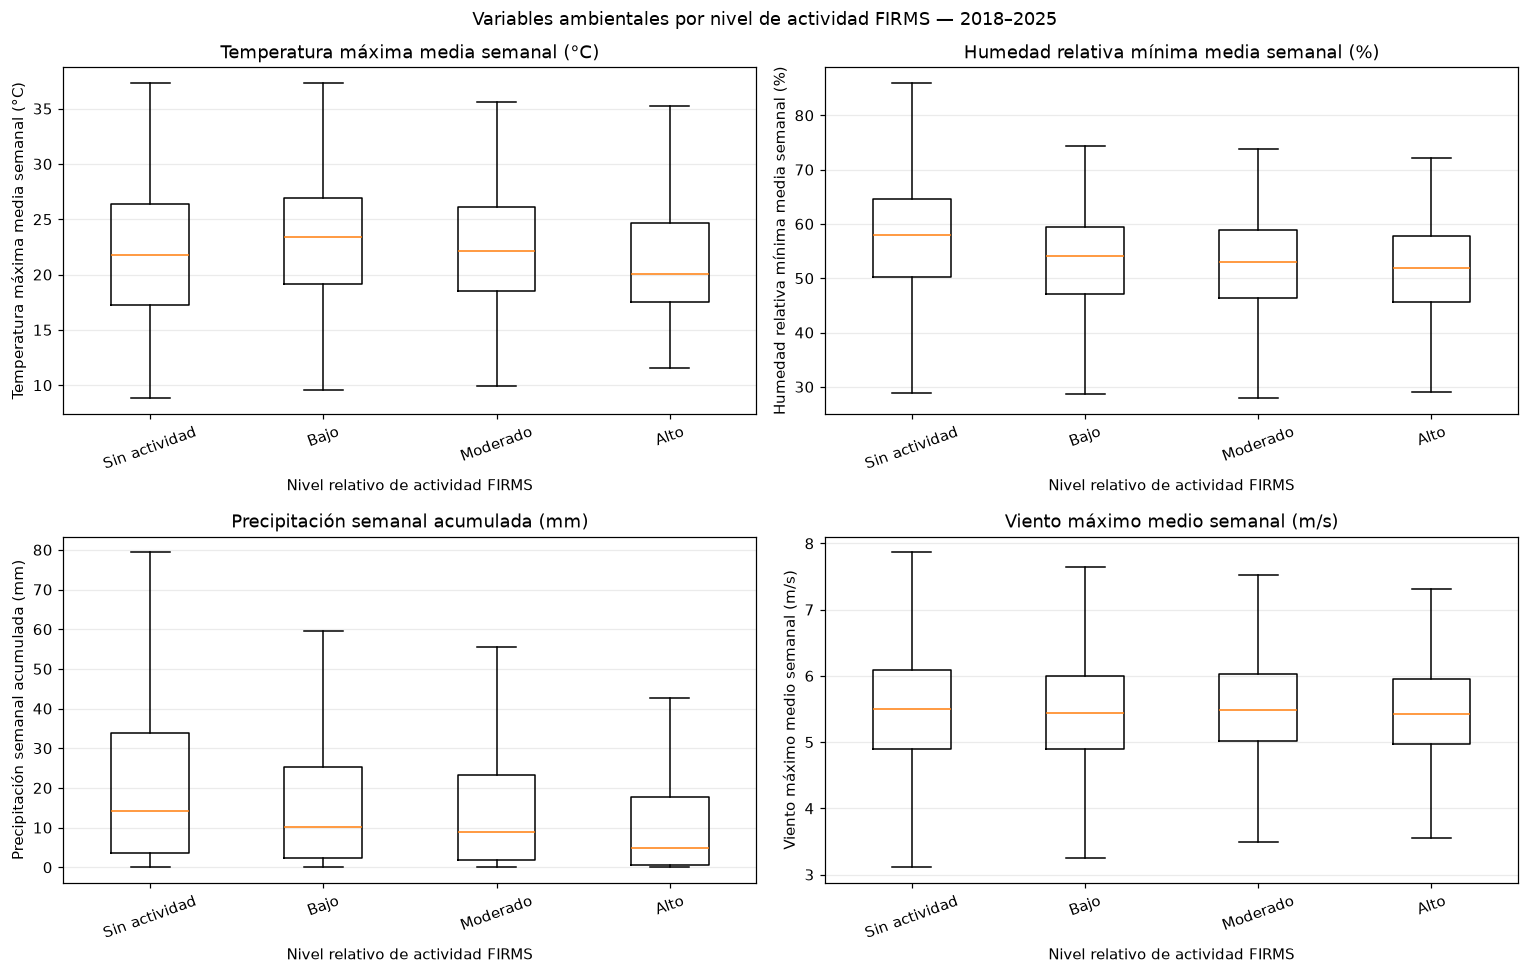

In [28]:
variables_graficos = {
    "temperature_2m_max_mean_weekly": "Temperatura máxima media semanal (°C)",
    "relative_humidity_2m_min_mean_weekly": "Humedad relativa mínima media semanal (%)",
    "precipitation_sum_weekly": "Precipitación semanal acumulada (mm)",
    "wind_speed_10m_max_mean_weekly": "Viento máximo medio semanal (m/s)"
}
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (variable, etiqueta) in zip(axes.ravel(), variables_graficos.items()):
    valores = [datos_caracterizados.loc[datos_caracterizados["nivel_actividad_kmeans"].eq(nivel), variable].dropna() for nivel in orden_niveles]
    ax.boxplot(valores, tick_labels=orden_niveles, showfliers=False)
    ax.set_title(etiqueta)
    ax.set_xlabel("Nivel relativo de actividad FIRMS")
    ax.set_ylabel(etiqueta)
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.25)
plt.suptitle("Variables ambientales por nivel de actividad FIRMS — 2018–2025")
plt.tight_layout()
plt.show()

## Distribución temporal

El mes se deriva de la fecha de inicio de semana. Las proporciones mensuales describen estacionalidad observada; no indican relaciones causales.

In [29]:
datos_caracterizados["mes"] = datos_caracterizados["fecha_inicio_semana"].dt.month
distribucion_mes = pd.crosstab(datos_caracterizados["mes"], datos_caracterizados["nivel_actividad_kmeans"], normalize="index").reindex(columns=orden_niveles, fill_value=0).mul(100)
distribucion_mes.round(2)

nivel_actividad_kmeans,Sin actividad,Bajo,Moderado,Alto
mes,,,,
1,57.60,19.74,17.25,5.41
2,71.22,13.82,12.50,2.47
3,77.89,11.43,8.42,2.26
4,70.53,13.83,11.43,4.21
5,68.72,12.93,11.73,6.62
6,79.88,8.20,8.51,3.41
7,70.76,11.11,14.62,3.51
8,46.62,16.24,21.95,15.19
9,51.73,14.74,21.20,12.33


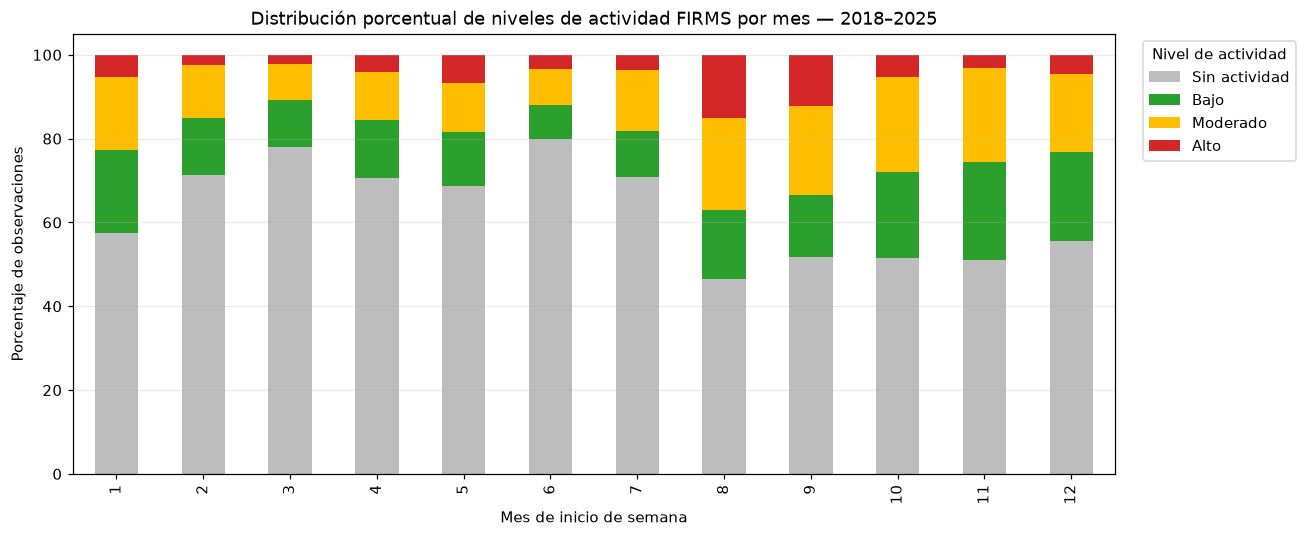

In [30]:
distribucion_mes.plot(kind="bar", stacked=True, figsize=(12, 5), color=["#bdbdbd", "#2ca02c", "#ffbf00", "#d62728"])
plt.title("Distribución porcentual de niveles de actividad FIRMS por mes — 2018–2025")
plt.xlabel("Mes de inicio de semana")
plt.ylabel("Porcentaje de observaciones")
plt.legend(title="Nivel de actividad", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Distribución espacial

Cada fila representa un departamento-semana. Se presentan conteos y porcentajes dentro de cada departamento. Una mayor proporción de nivel Alto no implica que un departamento sea intrínsecamente más riesgoso.

In [31]:
niveles_por_departamento = pd.crosstab(datos_caracterizados["departamento"], datos_caracterizados["nivel_actividad_kmeans"]).reindex(columns=orden_niveles, fill_value=0)
niveles_por_departamento

nivel_actividad_kmeans,Sin actividad,Bajo,Moderado,Alto
departamento,,,,
Artigas,211,69,99,38
Canelones,264,48,65,40
Cerro Largo,213,99,76,29
Colonia,260,54,73,30
Durazno,280,73,51,13
Flores,334,56,24,3
Florida,282,59,71,5
Lavalleja,196,79,103,39
Maldonado,266,61,76,14


In [32]:
porcentaje_niveles_departamento = pd.crosstab(datos_caracterizados["departamento"], datos_caracterizados["nivel_actividad_kmeans"], normalize="index").reindex(columns=orden_niveles, fill_value=0).mul(100)
porcentaje_niveles_departamento.round(2)

nivel_actividad_kmeans,Sin actividad,Bajo,Moderado,Alto
departamento,,,,
Artigas,50.60,16.55,23.74,9.11
Canelones,63.31,11.51,15.59,9.59
Cerro Largo,51.08,23.74,18.23,6.95
Colonia,62.35,12.95,17.51,7.19
Durazno,67.15,17.51,12.23,3.12
Flores,80.10,13.43,5.76,0.72
Florida,67.63,14.15,17.03,1.20
Lavalleja,47.00,18.94,24.70,9.35
Maldonado,63.79,14.63,18.23,3.36


## Conclusión del antecedente univariado

La solución univariada `k=3` produce rangos de `1`, `2–4` y `5 o más` detecciones positivas. Es útil como referencia de intensidad, pero no describe perfiles ambientales conjuntos y no constituye una definición definitiva de riesgo.

# Parte B — Clustering multivariado de perfiles históricos

La unidad de análisis es `departamento–semana`. La pregunta es si existen perfiles históricos que combinen actividad FIRMS y condiciones ambientales. A diferencia del antecedente univariado, se incluyen semanas con cero detecciones porque la ausencia observada también forma parte de los perfiles conjuntos.

## Auditoría y selección de variables

Se revisan cobertura, escala, redundancia e interpretabilidad. No se incorporan automáticamente todas las columnas disponibles.

In [33]:
auditoria_variables_cluster = pd.DataFrame([
    ["cantidad_detecciones", "detecciones/semana", "Sí", "log1p", "Actividad FIRMS observada"],
    ["temperature_2m_max_mean_weekly", "°C", "Sí", "ninguna", "Resumen térmico semanal interpretable"],
    ["relative_humidity_2m_min_mean_weekly", "%", "Sí", "ninguna", "Resumen de humedad mínima semanal"],
    ["wind_speed_10m_max_mean_weekly", "m/s", "Sí", "ninguna", "Resumen de viento máximo semanal"],
    ["precipitation_sum_weekly", "mm/semana", "Sí", "log1p", "Acumulado semanal con asimetría positiva"],
    ["temperature_2m_max_weekly", "°C", "No", "—", "Redundante con temperatura máxima media"],
    ["temperature_2m_min_mean_weekly", "°C", "No", "—", "Muy correlacionada con temperatura máxima media"],
    ["relative_humidity_2m_max_mean_weekly", "%", "No", "—", "Redundante con el resumen de humedad seleccionado"],
    ["wind_speed_10m_max_weekly", "m/s", "No", "—", "Redundante con viento máximo medio"],
    ["precipitation_max_daily_weekly", "mm/día", "No", "—", "Correlación alta con precipitación semanal"],
    ["et0_fao_evapotranspiration_sum_weekly", "mm/semana", "No", "—", "Alta correlación con temperatura y humedad"],
    ["wind_direction_10m_dominant_circular_mean_weekly", "grados", "No", "—", "Variable angular; requiere codificación circular"],
    ["wind_direction_10m_resultant_length_weekly", "0–1", "No", "—", "Describe concentración direccional, no una condición principal"],
], columns=["variable", "unidad", "incluida", "transformacion", "motivo"])

auditoria_variables_cluster["no_nulos_desarrollo"] = auditoria_variables_cluster["variable"].map(train.notna().sum())
auditoria_variables_cluster["faltantes_desarrollo"] = len(train) - auditoria_variables_cluster["no_nulos_desarrollo"]
auditoria_variables_cluster

,variable,unidad,incluida,transformacion,motivo,no_nulos_desarrollo,faltantes_desarrollo
0,cantidad_detecciones,detecciones/semana,Sí,log1p,Actividad FIRMS observada,5947,0
1,temperature_2m_max_mean_weekly,°C,Sí,ninguna,Resumen térmico semanal interpretable,5947,0
2,relative_humidity_2m_min_mean_weekly,%,Sí,ninguna,Resumen de humedad mínima semanal,5947,0
3,wind_speed_10m_max_mean_weekly,m/s,Sí,ninguna,Resumen de viento máximo semanal,5947,0
4,precipitation_sum_weekly,mm/semana,Sí,log1p,Acumulado semanal con asimetría positiva,5947,0
5,temperature_2m_max_weekly,°C,No,—,Redundante con temperatura máxima media,5947,0
6,temperature_2m_min_mean_weekly,°C,No,—,Muy correlacionada con temperatura máxima media,5947,0
7,relative_humidity_2m_max_mean_weekly,%,No,—,Redundante con el resumen de humedad seleccionado,5947,0
8,wind_speed_10m_max_weekly,m/s,No,—,Redundante con viento máximo medio,5947,0
9,precipitation_max_daily_weekly,mm/día,No,—,Correlación alta con precipitación semanal,5947,0


In [34]:
variables_cluster_originales = [
    "cantidad_detecciones",
    "temperature_2m_max_mean_weekly",
    "relative_humidity_2m_min_mean_weekly",
    "wind_speed_10m_max_mean_weekly",
    "precipitation_sum_weekly"
]

resumen_variables_desarrollo = train[variables_cluster_originales].describe().T
resumen_variables_desarrollo["faltantes"] = train[variables_cluster_originales].isna().sum()
resumen_variables_desarrollo.round(3)

,count,mean,std,min,25%,50%,75%,max,faltantes
cantidad_detecciones,5947.0,1.159744,3.458423,0.0,0.0,0.0,1.0,173.0,0
temperature_2m_max_mean_weekly,5947.0,22.0897,5.475177,9.539286,17.765476,21.87551,26.41875,37.302041,0
relative_humidity_2m_min_mean_weekly,5947.0,54.496496,10.710143,21.5625,47.804762,55.714286,62.33208,88.285714,0
wind_speed_10m_max_mean_weekly,5947.0,5.496637,0.867295,3.110286,4.920993,5.470476,6.056112,8.76,0
precipitation_sum_weekly,5947.0,20.218866,24.695072,0.0,2.487868,11.15,29.727381,195.925,0


## Preparación temporal, transformaciones y estandarización

`log1p` se aplica a detecciones y precipitación para reducir su asimetría. `StandardScaler` se ajusta exclusivamente con 2018–2023; 2024–2025 sólo se transforma posteriormente con los parámetros congelados. No se realizan imputaciones porque las cinco variables tienen cobertura completa.

In [35]:
def preparar_variables_cluster(dataframe):
    matriz = dataframe[variables_cluster_originales].astype(float).copy()
    matriz["cantidad_detecciones"] = np.log1p(matriz["cantidad_detecciones"])
    matriz["precipitation_sum_weekly"] = np.log1p(matriz["precipitation_sum_weekly"])
    return matriz

X_desarrollo_sin_escalar = preparar_variables_cluster(train)
assert X_desarrollo_sin_escalar.isna().sum().sum() == 0

scaler = StandardScaler()
X_desarrollo = scaler.fit_transform(X_desarrollo_sin_escalar)

pd.DataFrame(X_desarrollo, columns=variables_cluster_originales).agg(["mean", "std"]).round(3)

,cantidad_detecciones,temperature_2m_max_mean_weekly,relative_humidity_2m_min_mean_weekly,wind_speed_10m_max_mean_weekly,precipitation_sum_weekly
mean,0.0,0.0,-0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0


## K-Means multivariado y selección de k

Se evalúan `k=2…6` sobre la misma matriz estandarizada. La selección combina Silhouette, codo, tamaños, estabilidad e interpretabilidad; no se elige automáticamente el mayor valor de una métrica.

In [36]:
resultados_k_multivariado = []
modelos_k_multivariado = {}
for k in range(2, 7):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=20)
    etiquetas = modelo.fit_predict(X_desarrollo)
    modelos_k_multivariado[k] = modelo
    conteos = pd.Series(etiquetas).value_counts().sort_index()
    resultados_k_multivariado.append({
        "k": k,
        "inercia": modelo.inertia_,
        "silhouette": silhouette_score(X_desarrollo, etiquetas),
        "minimo_cluster": int(conteos.min()),
        "maximo_cluster": int(conteos.max()),
        "tamanos": conteos.tolist(),
        "porcentajes": conteos.div(len(etiquetas)).mul(100).round(2).tolist()
    })
resultados_k_multivariado = pd.DataFrame(resultados_k_multivariado)
resultados_k_multivariado.round(4)

,k,inercia,silhouette,minimo_cluster,maximo_cluster,tamanos,porcentajes
0,2,22691.5464,0.2193,2815,3132,"[2815, 3132]","[47.33, 52.67]"
1,3,18312.0803,0.2268,1827,2248,"[1827, 2248, 1872]","[30.72, 37.8, 31.48]"
2,4,15536.7001,0.2339,1053,1867,"[1053, 1491, 1536, 1867]","[17.71, 25.07, 25.83, 31.39]"
3,5,13821.0811,0.2178,979,1343,"[1343, 1292, 1275, 1058, 979]","[22.58, 21.73, 21.44, 17.79, 16.46]"
4,6,12780.5526,0.1988,894,1194,"[894, 999, 1042, 1194, 894, 924]","[15.03, 16.8, 17.52, 20.08, 15.03, 15.54]"


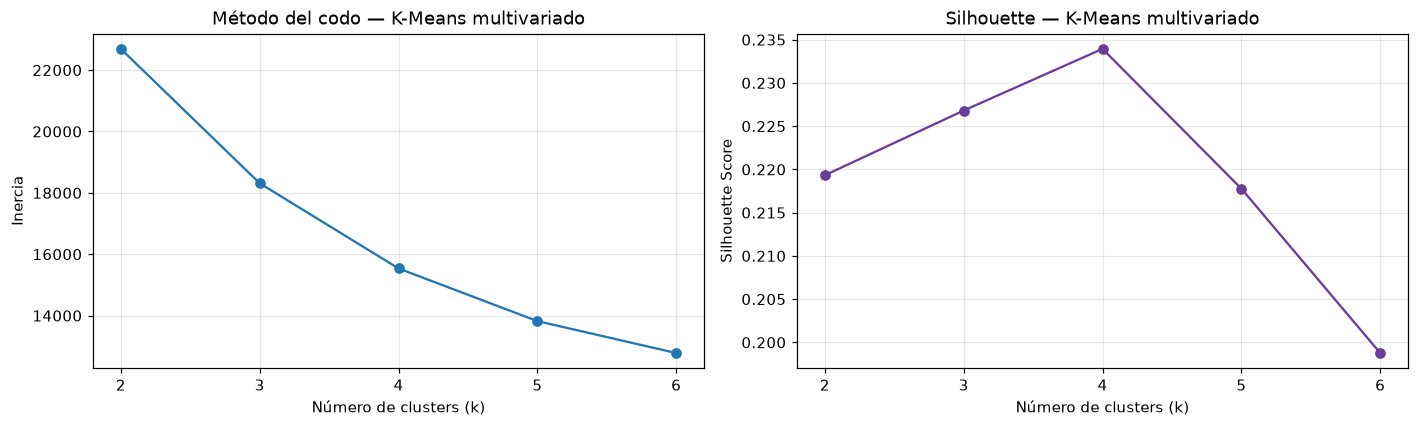

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(resultados_k_multivariado["k"], resultados_k_multivariado["inercia"], marker="o")
axes[0].set_title("Método del codo — K-Means multivariado")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inercia")
axes[0].set_xticks(resultados_k_multivariado["k"])
axes[0].grid(alpha=0.3)
axes[1].plot(resultados_k_multivariado["k"], resultados_k_multivariado["silhouette"], marker="o", color="#6a3d9a")
axes[1].set_title("Silhouette — K-Means multivariado")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(resultados_k_multivariado["k"])
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

En el rango evaluado, `k=4` alcanza el mayor Silhouette antes de que la métrica disminuya y conserva grupos de tamaño suficiente. Se adopta como solución multivariada provisional; esto no implica que sea la única estructura válida.

In [38]:
K_MULTIVARIADO = 4
kmeans_multivariado = modelos_k_multivariado[K_MULTIVARIADO]
train_multivariado = train.copy()
train_multivariado["cluster_kmeans"] = kmeans_multivariado.labels_

orden_por_actividad = (
    train_multivariado.groupby("cluster_kmeans")["cantidad_detecciones"].mean().sort_values().index
)
mapa_perfiles_kmeans = {int(cluster): f"Perfil {posicion}" for posicion, cluster in enumerate(orden_por_actividad, start=1)}
orden_perfiles = list(mapa_perfiles_kmeans.values())
train_multivariado["perfil_kmeans"] = train_multivariado["cluster_kmeans"].map(mapa_perfiles_kmeans)

tamanos_kmeans = train_multivariado["perfil_kmeans"].value_counts().reindex(orden_perfiles).rename("observaciones").to_frame()
tamanos_kmeans["porcentaje"] = tamanos_kmeans["observaciones"].div(len(train_multivariado)).mul(100)
tamanos_kmeans.round(3)

,observaciones,porcentaje
perfil_kmeans,,
Perfil 1,1867,31.394
Perfil 2,1491,25.071
Perfil 3,1536,25.828
Perfil 4,1053,17.706


In [39]:
perfiles_kmeans = train_multivariado.groupby("perfil_kmeans")[variables_cluster_originales].agg(["mean", "median"]).reindex(orden_perfiles)
perfiles_kmeans.round(3)

cantidad_detecciones        temperature_2m_max_mean_weekly  \
                              mean median                           mean   
perfil_kmeans                                                              
Perfil 1                      0.27    0.0                         20.156   
Perfil 2                       0.3    0.0                         18.738   
Perfil 3                     0.548    0.0                         28.399   
Perfil 4                     4.847    3.0                         21.061   

                      relative_humidity_2m_min_mean_weekly          \
               median                                 mean  median   
perfil_kmeans                                                        
Perfil 1       20.013                               62.812  63.052   
Perfil 2       18.537                               58.295  57.988   
Perfil 3       28.440                               42.359  42.732   
Perfil 4       20.583                               52.079  52.619   

              wind_speed_10m_max_mean_weekly        precipitation_sum_weekly  \
                                        mean median                     mean   
perfil_kmeans                                                                  
Perfil 1                               6.088  6.065                   41.584   
Perfil 2                               4.757  4.782                    6.333   
Perfil 3                               5.487  5.498                   13.234   
Perfil 4                               5.509  5.460                   12.190   

                       
               median  
perfil_kmeans          
Perfil 1       35.278  
Perfil 2        2.742  
Perfil 3        8.034  
Perfil 4        5.875

In [40]:
centroides_originales = pd.DataFrame(
    scaler.inverse_transform(kmeans_multivariado.cluster_centers_),
    columns=variables_cluster_originales
)
centroides_originales["cantidad_detecciones"] = np.expm1(centroides_originales["cantidad_detecciones"])
centroides_originales["precipitation_sum_weekly"] = np.expm1(centroides_originales["precipitation_sum_weekly"])
centroides_originales["perfil"] = centroides_originales.index.map(mapa_perfiles_kmeans)
centroides_originales.set_index("perfil").reindex(orden_perfiles).round(3)

,cantidad_detecciones,temperature_2m_max_mean_weekly,relative_humidity_2m_min_mean_weekly,wind_speed_10m_max_mean_weekly,precipitation_sum_weekly
perfil,,,,,
Perfil 1,0.177,20.159,62.808,6.089,32.646
Perfil 2,0.212,18.743,58.298,4.758,3.121
Perfil 3,0.368,28.398,42.354,5.486,6.905
Perfil 4,3.898,21.061,52.079,5.509,5.550


## Interpretación visual de K-Means

El heatmap muestra medias estandarizadas por perfil: valores positivos están por encima de la media de desarrollo y valores negativos por debajo. PCA se utiliza sólo para representar en dos dimensiones la solución obtenida con las variables originales estandarizadas.

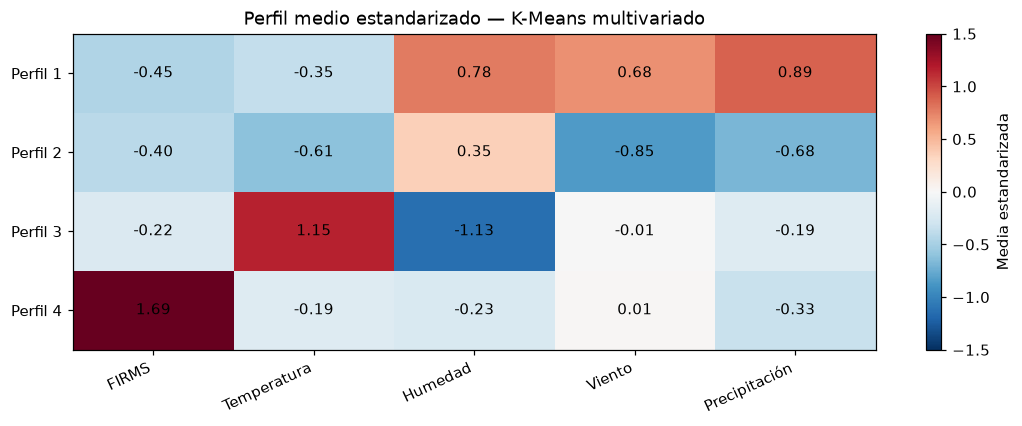

In [41]:
perfiles_estandarizados = pd.DataFrame(X_desarrollo, columns=variables_cluster_originales)
perfiles_estandarizados["perfil"] = train_multivariado["perfil_kmeans"].to_numpy()
medias_estandarizadas = perfiles_estandarizados.groupby("perfil")[variables_cluster_originales].mean().reindex(orden_perfiles)
fig, ax = plt.subplots(figsize=(10, 4))
imagen = ax.imshow(medias_estandarizadas, cmap="RdBu_r", aspect="auto", vmin=-1.5, vmax=1.5)
ax.set_xticks(range(len(variables_cluster_originales)), labels=["FIRMS", "Temperatura", "Humedad", "Viento", "Precipitación"], rotation=25, ha="right")
ax.set_yticks(range(len(orden_perfiles)), labels=orden_perfiles)
ax.set_title("Perfil medio estandarizado — K-Means multivariado")
for fila in range(medias_estandarizadas.shape[0]):
    for columna in range(medias_estandarizadas.shape[1]):
        ax.text(columna, fila, f"{medias_estandarizadas.iloc[fila, columna]:.2f}", ha="center", va="center")
fig.colorbar(imagen, ax=ax, label="Media estandarizada")
plt.tight_layout()
plt.show()

,proporcion_varianza_explicada
PC1,0.3650
PC2,0.2595


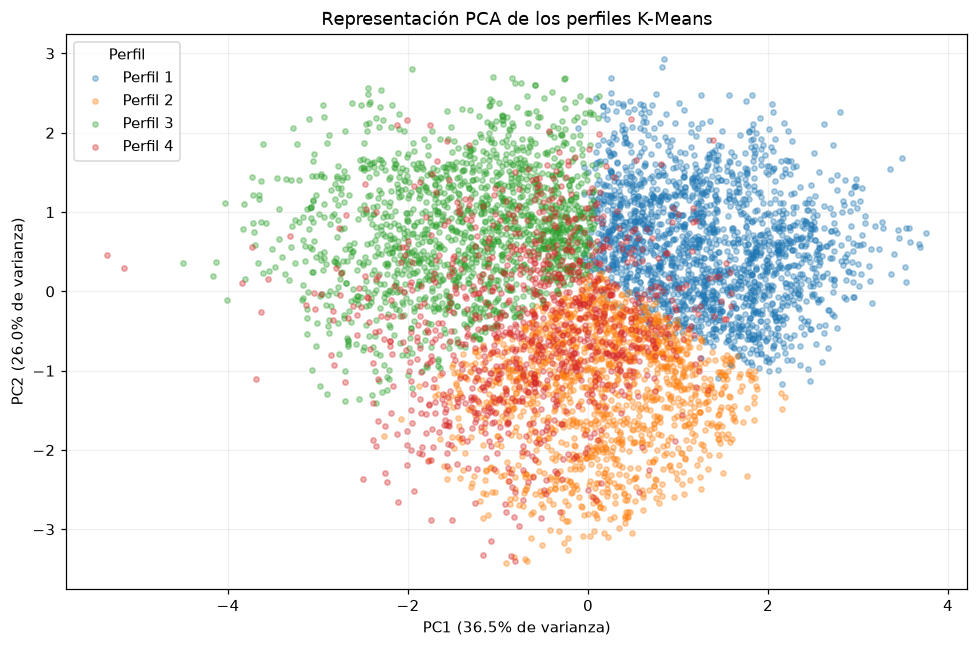

In [42]:
pca = PCA(n_components=2)
componentes = pca.fit_transform(X_desarrollo)
pca_resultados = pd.DataFrame(componentes, columns=["PC1", "PC2"])
pca_resultados["perfil"] = train_multivariado["perfil_kmeans"].to_numpy()

fig, ax = plt.subplots(figsize=(9, 6))
for perfil in orden_perfiles:
    parte = pca_resultados[pca_resultados["perfil"].eq(perfil)]
    ax.scatter(parte["PC1"], parte["PC2"], s=12, alpha=0.35, label=perfil)
ax.set_title("Representación PCA de los perfiles K-Means")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% de varianza)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% de varianza)")
ax.legend(title="Perfil")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

pd.Series(pca.explained_variance_ratio_, index=["PC1", "PC2"], name="proporcion_varianza_explicada").to_frame().round(4)

## Estabilidad de K-Means

Se compara la solución final con varias semillas mediante Adjusted Rand Index (ARI). Valores cercanos a 1 indican asignaciones prácticamente iguales, independientemente de la numeración arbitraria de los clusters.

In [43]:
etiquetas_referencia = kmeans_multivariado.labels_
estabilidad_kmeans = []
for semilla in [0, 1, 7, 21, 42, 99]:
    etiquetas_semilla = KMeans(n_clusters=K_MULTIVARIADO, random_state=semilla, n_init=20).fit_predict(X_desarrollo)
    estabilidad_kmeans.append({"random_state": semilla, "ARI_vs_semilla_42": adjusted_rand_score(etiquetas_referencia, etiquetas_semilla)})
estabilidad_kmeans = pd.DataFrame(estabilidad_kmeans)
estabilidad_kmeans.round(4)

,random_state,ARI_vs_semilla_42
0,0,0.9883
1,1,0.9929
2,7,0.9912
3,21,0.9883
4,42,1.0000
5,99,0.9954


## Segundo método: clustering jerárquico aglomerativo

Se utiliza `AgglomerativeClustering` con enlace Ward sobre exactamente la misma matriz estandarizada. Se evalúa `k=2…6`. No se genera un dendrograma completo porque 5.947 hojas serían ilegibles y no aportarían una decisión interpretable.

In [44]:
resultados_aglomerativo = []
modelos_aglomerativos = {}
for k in range(2, 7):
    modelo = AgglomerativeClustering(n_clusters=k, linkage="ward")
    etiquetas = modelo.fit_predict(X_desarrollo)
    modelos_aglomerativos[k] = (modelo, etiquetas)
    conteos = pd.Series(etiquetas).value_counts().sort_index()
    resultados_aglomerativo.append({
        "k": k,
        "silhouette": silhouette_score(X_desarrollo, etiquetas),
        "minimo_cluster": int(conteos.min()),
        "maximo_cluster": int(conteos.max()),
        "tamanos": conteos.tolist(),
        "porcentajes": conteos.div(len(etiquetas)).mul(100).round(2).tolist()
    })
resultados_aglomerativo = pd.DataFrame(resultados_aglomerativo)
resultados_aglomerativo.round(4)

,k,silhouette,minimo_cluster,maximo_cluster,tamanos,porcentajes
0,2,0.1686,1896,4051,"[4051, 1896]","[68.12, 31.88]"
1,3,0.1655,1781,2270,"[2270, 1896, 1781]","[38.17, 31.88, 29.95]"
2,4,0.1827,1102,1896,"[1781, 1896, 1168, 1102]","[29.95, 31.88, 19.64, 18.53]"
3,5,0.1383,801,1896,"[1896, 1102, 1168, 801, 980]","[31.88, 18.53, 19.64, 13.47, 16.48]"
4,6,0.1312,801,1168,"[1168, 1102, 883, 801, 980, 1013]","[19.64, 18.53, 14.85, 13.47, 16.48, 17.03]"


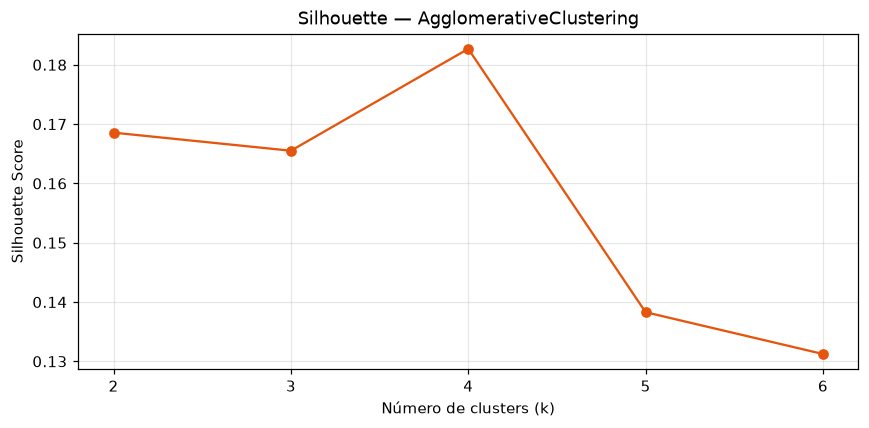

In [45]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(resultados_aglomerativo["k"], resultados_aglomerativo["silhouette"], marker="o", color="#e6550d")
ax.set_title("Silhouette — AgglomerativeClustering")
ax.set_xlabel("Número de clusters (k)")
ax.set_ylabel("Silhouette Score")
ax.set_xticks(resultados_aglomerativo["k"])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [46]:
aglomerativo_final, etiquetas_aglomerativo = modelos_aglomerativos[K_MULTIVARIADO]
train_multivariado["cluster_aglomerativo"] = etiquetas_aglomerativo
orden_aglomerativo = train_multivariado.groupby("cluster_aglomerativo")["cantidad_detecciones"].mean().sort_values().index
mapa_perfiles_aglomerativo = {int(cluster): f"Perfil {posicion}" for posicion, cluster in enumerate(orden_aglomerativo, start=1)}
train_multivariado["perfil_aglomerativo"] = train_multivariado["cluster_aglomerativo"].map(mapa_perfiles_aglomerativo)

perfiles_aglomerativo = train_multivariado.groupby("perfil_aglomerativo")[variables_cluster_originales].agg(["count", "mean", "median"]).reindex(orden_perfiles)
perfiles_aglomerativo.round(3)

cantidad_detecciones                \
                                   count   mean median   
perfil_aglomerativo                                      
Perfil 1                            1781   0.03    0.0   
Perfil 2                            1102  0.351    0.0   
Perfil 3                            1896  1.147    0.0   
Perfil 4                            1168  3.666    2.0   

                    temperature_2m_max_mean_weekly                  \
                                             count    mean  median   
perfil_aglomerativo                                                  
Perfil 1                                      1781  19.809  19.506   
Perfil 2                                      1102  18.917  18.348   
Perfil 3                                      1896  27.510  27.667   
Perfil 4                                      1168  19.763  19.368   

                    relative_humidity_2m_min_mean_weekly                  \
                                                   count    mean  median   
perfil_aglomerativo                                                        
Perfil 1                                            1781  63.088  63.277   
Perfil 2                                            1102  56.186  56.176   
Perfil 3                                            1896  44.359  44.709   
Perfil 4                                            1168  56.258  56.552   

                    wind_speed_10m_max_mean_weekly                \
                                             count   mean median   
perfil_aglomerativo                                                
Perfil 1                                      1781  5.797  5.758   
Perfil 2                                      1102  4.775  4.683   
Perfil 3                                      1896  5.536  5.509   
Perfil 4                                      1168  5.656  5.575   

                    precipitation_sum_weekly                  
                                       count    mean  median  
perfil_aglomerativo                                           
Perfil 1                                1781  37.095  31.164  
Perfil 2                                1102   2.701   1.045  
Perfil 3                                1896  14.858   8.863  
Perfil 4                                1168  19.715  10.262

## Comparación de métodos de clustering

Se comparan separación, tamaños, coincidencia y uso temporal. Una diferencia pequeña de Silhouette no basta por sí sola para escoger un método.

In [47]:
comparacion_metodos = pd.DataFrame([
    {
        "metodo": "K-Means",
        "k": K_MULTIVARIADO,
        "silhouette": silhouette_score(X_desarrollo, kmeans_multivariado.labels_),
        "tamano_minimo": tamanos_kmeans["observaciones"].min(),
        "tamano_maximo": tamanos_kmeans["observaciones"].max(),
        "asignacion_periodo_posterior": "predict disponible"
    },
    {
        "metodo": "AgglomerativeClustering",
        "k": K_MULTIVARIADO,
        "silhouette": silhouette_score(X_desarrollo, etiquetas_aglomerativo),
        "tamano_minimo": int(pd.Series(etiquetas_aglomerativo).value_counts().min()),
        "tamano_maximo": int(pd.Series(etiquetas_aglomerativo).value_counts().max()),
        "asignacion_periodo_posterior": "sin predict directo"
    }
])
ari_metodos = adjusted_rand_score(kmeans_multivariado.labels_, etiquetas_aglomerativo)
print("ARI entre métodos:", round(ari_metodos, 4))
comparacion_metodos.round(4)

ARI entre métodos: 0.4409


,metodo,k,silhouette,tamano_minimo,tamano_maximo,asignacion_periodo_posterior
0,K-Means,4,0.2339,1053,1867,predict disponible
1,AgglomerativeClustering,4,0.1827,1102,1896,sin predict directo


K-Means logra mayor Silhouette y muestra alta estabilidad entre inicializaciones. AgglomerativeClustering confirma que existen perfiles ambientales diferenciables, pero coincide sólo moderadamente con K-Means y no ofrece `predict` para datos nuevos. Por estas razones se conserva K-Means como método multivariado principal provisional.

## Patrones temporales y por departamento

Estas tablas describen cómo se distribuyen los perfiles K-Means durante desarrollo. No prueban causalidad ni convierten los perfiles en categorías oficiales de riesgo.

perfil_kmeans,Perfil 1,Perfil 2,Perfil 3,Perfil 4
mes,,,,
1,19.69,0.58,68.81,10.92
2,18.64,6.80,66.23,8.33
3,31.98,23.68,36.03,8.30
4,26.11,50.40,6.68,16.80
5,36.84,45.61,0.00,17.54
6,35.37,57.26,0.00,7.37
7,45.03,40.74,0.00,14.23
8,37.82,27.49,0.19,34.50
9,47.58,20.63,0.21,31.58


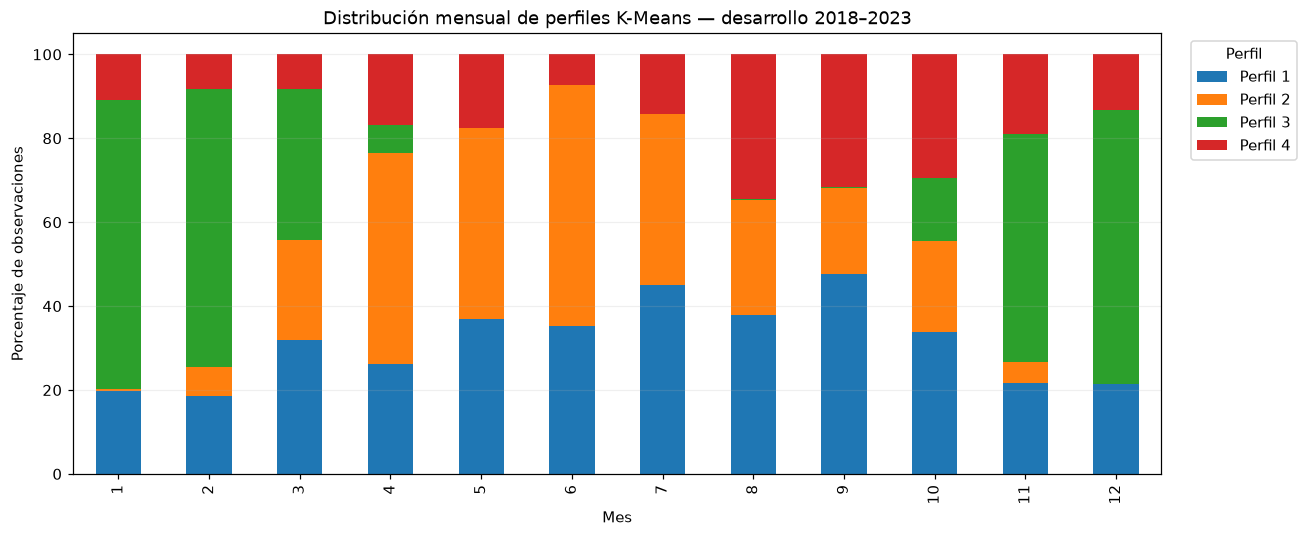

In [48]:
train_multivariado["mes"] = train_multivariado["fecha_inicio_semana"].dt.month
perfiles_por_mes = pd.crosstab(train_multivariado["mes"], train_multivariado["perfil_kmeans"], normalize="index").reindex(columns=orden_perfiles, fill_value=0).mul(100)
perfiles_por_mes.plot(kind="bar", stacked=True, figsize=(12, 5))
plt.title("Distribución mensual de perfiles K-Means — desarrollo 2018–2023")
plt.xlabel("Mes")
plt.ylabel("Porcentaje de observaciones")
plt.legend(title="Perfil", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()
perfiles_por_mes.round(2)

In [49]:
perfiles_por_departamento = pd.crosstab(train_multivariado["departamento"], train_multivariado["perfil_kmeans"], normalize="index").reindex(columns=orden_perfiles, fill_value=0).mul(100)
perfiles_por_departamento.round(2)

perfil_kmeans,Perfil 1,Perfil 2,Perfil 3,Perfil 4
departamento,,,,
Artigas,28.43,15.97,35.78,19.81
Canelones,31.31,32.27,15.97,20.45
Cerro Largo,29.07,27.16,22.36,21.41
Colonia,23.64,23.32,30.35,22.68
Durazno,32.59,27.48,27.80,12.14
Flores,29.71,32.59,31.95,5.75
Florida,31.95,31.63,25.56,10.86
Lavalleja,27.16,27.48,17.89,27.48
Maldonado,53.35,16.93,9.58,20.13


## Evaluación temporal externa multivariada

Se congelan el `StandardScaler` y K-Means ajustados en 2018–2023. Para 2024–2025 se ejecutan solamente `scaler.transform` y `kmeans.predict`. AgglomerativeClustering no se aplica externamente porque no dispone de `predict`; no se inventa una regla equivalente.

In [50]:
datos_posteriores_multivariado = datos.loc[datos["fecha_inicio_semana"].between("2024-01-01", "2025-12-31")].copy()
X_posterior_sin_escalar = preparar_variables_cluster(datos_posteriores_multivariado)
X_posterior_multivariado = scaler.transform(X_posterior_sin_escalar)
datos_posteriores_multivariado["cluster_kmeans"] = kmeans_multivariado.predict(X_posterior_multivariado)
datos_posteriores_multivariado["perfil_kmeans"] = datos_posteriores_multivariado["cluster_kmeans"].map(mapa_perfiles_kmeans)

distribucion_externa_multivariada = pd.DataFrame({
    "% desarrollo": train_multivariado["perfil_kmeans"].value_counts(normalize=True).reindex(orden_perfiles).mul(100),
    "% 2024–2025": datos_posteriores_multivariado["perfil_kmeans"].value_counts(normalize=True).reindex(orden_perfiles).mul(100)
})
distribucion_externa_multivariada["diferencia pp"] = distribucion_externa_multivariada["% 2024–2025"] - distribucion_externa_multivariada["% desarrollo"]
distribucion_externa_multivariada.round(3)

,% desarrollo,% 2024–2025,diferencia pp
perfil_kmeans,,,
Perfil 1,31.394,39.676,8.282
Perfil 2,25.071,23.887,-1.185
Perfil 3,25.828,23.583,-2.245
Perfil 4,17.706,12.854,-4.852


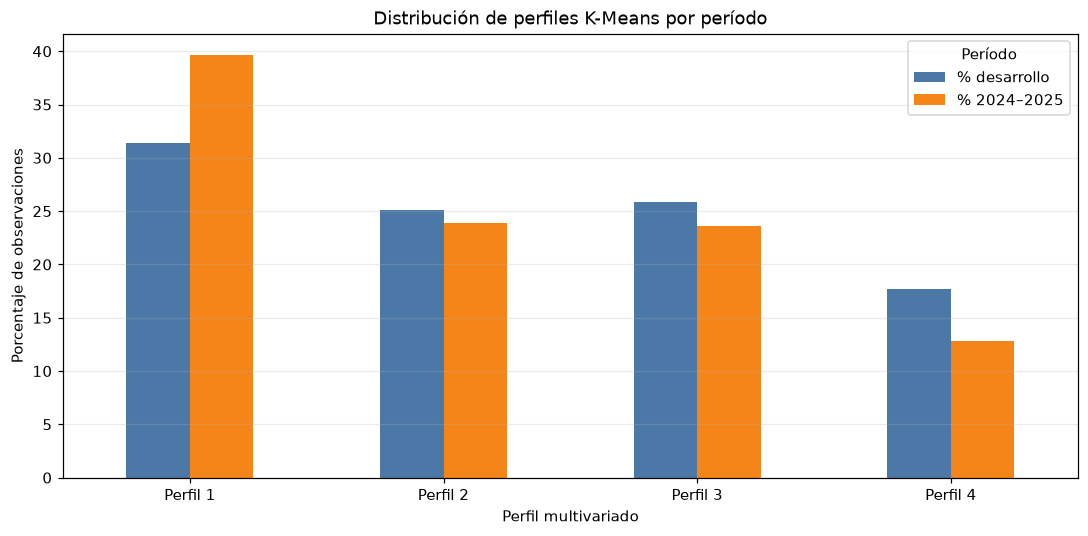

In [51]:
distribucion_externa_multivariada[["% desarrollo", "% 2024–2025"]].plot(kind="bar", figsize=(10, 5), color=["#4c78a8", "#f58518"])
plt.title("Distribución de perfiles K-Means por período")
plt.xlabel("Perfil multivariado")
plt.ylabel("Porcentaje de observaciones")
plt.xticks(rotation=0)
plt.legend(title="Período")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

In [52]:
perfiles_externos = datos_posteriores_multivariado.groupby("perfil_kmeans")[variables_cluster_originales].agg(["count", "mean", "median"]).reindex(orden_perfiles)
perfiles_externos.round(3)

cantidad_detecciones                \
                             count   mean median   
perfil_kmeans                                      
Perfil 1                       784  0.216    0.0   
Perfil 2                       472  0.275    0.0   
Perfil 3                       466  0.416    0.0   
Perfil 4                       254  4.402    3.0   

              temperature_2m_max_mean_weekly                  \
                                       count    mean  median   
perfil_kmeans                                                  
Perfil 1                                 784  20.777  21.074   
Perfil 2                                 472  18.156  18.149   
Perfil 3                                 466  28.100  28.015   
Perfil 4                                 254  21.704  22.104   

              relative_humidity_2m_min_mean_weekly                  \
                                             count    mean  median   
perfil_kmeans                                                        
Perfil 1                                       784  62.499  63.121   
Perfil 2                                       472  58.874  58.464   
Perfil 3                                       466  46.513  46.695   
Perfil 4                                       254  54.017  53.686   

              wind_speed_10m_max_mean_weekly                \
                                       count   mean median   
perfil_kmeans                                                
Perfil 1                                 784  6.031  5.962   
Perfil 2                                 472  4.617  4.592   
Perfil 3                                 466  5.434  5.415   
Perfil 4                                 254  5.641  5.589   

              precipitation_sum_weekly                  
                                 count    mean  median  
perfil_kmeans                                           
Perfil 1                           784  40.744  33.270  
Perfil 2                           472   5.331   2.359  
Perfil 3                           466  13.751  10.310  
Perfil 4                           254  13.199   9.117

# Limitaciones y conclusión del análisis multivariado

El análisis multivariado identifica cuatro perfiles conjuntos, pero sus Silhouette son modestos: la separación no es fuerte ni demuestra una estructura natural única. K-Means supone grupos aproximadamente compactos en el espacio estandarizado y asigna el mismo peso a cada dimensión seleccionada. La actividad FIRMS tiene muchos ceros y valores extremos; además, temperatura, humedad y precipitación conservan relaciones estacionales.

`k=4` es provisionalmente razonable porque ofrece la mejor Silhouette de K-Means entre `k=2…6` antes de una caída, tamaños adecuados, perfiles interpretables y alta estabilidad entre semillas. AgglomerativeClustering obtiene menor Silhouette, una coincidencia moderada con K-Means y no permite asignación externa directa.

Los perfiles deben denominarse por ahora `Perfil 1–4` y describirse mediante actividad y ambiente. No son categorías oficiales de INUMET, no equivalen a riesgo de incendio y no prueban causalidad. Antes de construir el target supervisado corresponde discutir con los docentes si el objetivo será reproducir estos perfiles multivariados o definir niveles centrados principalmente en actividad FIRMS.

## Próximos pasos hacia el modelo supervisado

El siguiente paso, después de aprobar la solución de clustering, será fijar una regla reproducible para etiquetar las observaciones y recién entonces retomar `Modelos.ipynb`. En esta etapa no se entrenó ni modificó ningún modelo supervisado.